In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import sem, t
from sklearn.metrics import r2_score
from sklearn.metrics.pairwise import cosine_similarity

# ----------------- 全局参数（调参只需改这里） -----------------
n_folds        = 10
embed_dir      = './k_folds_model/embeddings'
pred_dir       = './k_folds_model/xgb_predictions'

# 邻居比例：用于 Top-k(q) 和 Top-k_swd(t)
K_RATIO_GLOBAL = 0.1   # 用于初次收集 rho/IA 的比例
K_RATIO_SCAN   = 0.1    # 用于网格统计时的比例

# 权重函数参数
A_WEIGHT       = 100000.0
EPSILON        = 1e-3

# 网格分辨率
GRID_SIZE      = 40

# ----------------- AD 辅助函数 -----------------
def compute_weights(sim_vals, a=A_WEIGHT, epsilon=EPSILON):
    # 1) 将 [-1,1] 映射到 [0,1]
    s = (sim_vals + 1.0) / 2.0
    # 2) clip 到 [ε,1]
    s = np.clip(s, epsilon, 1.0)
    # 3) 计算权重
    return np.exp(-a * (1 - s) / s)

def compute_SWD_topk(X_train, y_train, k_swd, a=A_WEIGHT, epsilon=EPSILON):
    sim_train = cosine_similarity(X_train)
    sim_train = np.clip(sim_train, 0.0, 1.0)
    N = sim_train.shape[0]
    k_eff = max(1, min(k_swd, N-1))
    SWD = np.zeros(N)
    for t in range(N):
        sims_t = sim_train[t]
        if k_eff < N-1:
            idxs = np.argpartition(sims_t, -(k_eff+1))[-(k_eff+1):]
            idxs = idxs[idxs != t]
        else:
            idxs = np.delete(np.arange(N), t)
        if idxs.size == 0:
            continue
        sim_vals = sims_t[idxs]
        w_vals   = compute_weights(sim_vals)
        diffs    = np.abs(y_train[t] - y_train[idxs])
        SWD[t]   = (w_vals * sim_vals * diffs).sum() / (w_vals.sum() + epsilon)
    return SWD

def compute_rho_IA_topk(X_train, y_train, X_test,
                        k, k_swd, a=A_WEIGHT, epsilon=EPSILON):
    SWD = compute_SWD_topk(X_train, y_train, k_swd)
    sim_qt = cosine_similarity(X_test, X_train)
    sim_qt = np.clip(sim_qt, 0.0, 1.0)
    M = sim_qt.shape[0]
    rho_s = np.zeros(M)
    IA    = np.zeros(M)
    for i in range(M):
        sims  = sim_qt[i]
        idx_k = np.argpartition(sims, -k)[-k:]
        sim_k = sims[idx_k]
        w_k   = compute_weights(sim_k)
        rho_s[i] = w_k.mean()
        IA[i]    = (w_k * SWD[idx_k]).sum() / (w_k.sum() + epsilon)
    return rho_s, IA

# ----------------- 收集 rho_s / IA 分布 -----------------
all_rho, all_IA = [], []
for fold in range(1, n_folds+1):
    X_tr = np.load(f'{embed_dir}/train_fold_{fold}.npy')[:, :768]
    y_tr = np.load(f'{embed_dir}/train_labels_fold_{fold}.npy')
    X_te = np.load(f'{embed_dir}/val_fold_{fold}.npy')[:, :768]

    k0 = max(int(K_RATIO_GLOBAL * X_tr.shape[0]), 1)
    rho_s, IA = compute_rho_IA_topk(X_tr, y_tr, X_te,
                                    k=k0, k_swd=k0)
    all_rho.append(rho_s)
    all_IA .append(IA)

all_rho = np.concatenate(all_rho)
all_IA  = np.concatenate(all_IA)

rho_low, rho_high = all_rho.min(), all_rho.max()
IA_low,  IA_high  = all_IA.min(),  all_IA.max()

rho_cuts = np.linspace(rho_low, rho_high, GRID_SIZE)
IA_cuts  = np.linspace(IA_low,  IA_high,  GRID_SIZE)

# ----------------- 十折网格统计 -----------------
mean_n      = np.zeros((GRID_SIZE, GRID_SIZE))
mean_r2_in  = np.zeros_like(mean_n)
mean_r2_out = np.zeros_like(mean_n)
counts_list, r2in_list, r2out_list = [], [], []

for fold in range(1, n_folds+1):
    X_tr = np.load(f'{embed_dir}/train_fold_{fold}.npy')[:, :768]
    y_tr = np.load(f'{embed_dir}/train_labels_fold_{fold}.npy')
    X_te = np.load(f'{embed_dir}/val_fold_{fold}.npy')[:, :768]
    y_te = np.load(f'{embed_dir}/val_labels_fold_{fold}.npy')
    y_pr= np.load(f'{pred_dir}/fold_{fold}_y_pred.npy')

    k1 = max(int(K_RATIO_SCAN * X_tr.shape[0]), 1)
    rho_s, IA = compute_rho_IA_topk(X_tr, y_tr, X_te,
                                    k=k1, k_swd=k1)

    cnt   = np.zeros_like(mean_n)
    r2in  = np.zeros_like(mean_n)
    r2out = np.zeros_like(mean_n)

    for i, ia_th in enumerate(IA_cuts):
        for j, rho_th in enumerate(rho_cuts):
            in_m  = (rho_s >= rho_th) & (IA <= ia_th)
            out_m = ~in_m
            cnt[i,j] = in_m.sum()
            if in_m.sum()>1:
                r2in[i,j]  = r2_score(y_te[in_m],  y_pr[in_m])
            if out_m.sum()>1:
                r2out[i,j] = r2_score(y_te[out_m], y_pr[out_m])
            mean_n[i,j]     += cnt[i,j]
            mean_r2_in[i,j] += np.nan_to_num(r2in[i,j])
            mean_r2_out[i,j]+= np.nan_to_num(r2out[i,j])

    counts_list.append(cnt)
    r2in_list  .append(r2in)
    r2out_list .append(r2out)

# 平均十折
mean_n      /= n_folds
mean_r2_in  /= n_folds
mean_r2_out /= n_folds

# ----------------- 计算 95% CI -----------------
counts_arr = np.stack(counts_list, axis=0)
r2in_arr   = np.stack(r2in_list,   axis=0)
r2out_arr  = np.stack(r2out_list,  axis=0)
tval       = t.ppf(0.975, df=n_folds-1)

ci_n       = sem(counts_arr, axis=0, nan_policy='omit') * tval
ci_r2in    = sem(r2in_arr,   axis=0, nan_policy='omit') * tval
ci_r2out   = sem(r2out_arr,  axis=0, nan_policy='omit') * tval

# ----------------- 导出 CSV -----------------
records=[]
N_test = X_te.shape[0]
for i, ia_th in enumerate(IA_cuts):
    for j, rho_th in enumerate(rho_cuts):
        records.append({
            'rho_th':      rho_th,
            'IA_th':       ia_th,
            'count_in':    mean_n[i,j],
            'count_in_CI': ci_n[i,j],
            'count_out':   N_test-mean_n[i,j],
            'r2_in':       mean_r2_in[i,j],
            'r2in_CI':     ci_r2in[i,j],
            'r2_out':      mean_r2_out[i,j],
            'r2out_CI':    ci_r2out[i,j],
        })
df = pd.DataFrame(records)
df.to_csv('AD_grid_stats-0.1.csv', index=False)
print("导出完毕：AD_grid_stats.csv")

# ----------------- 绘图 -----------------
X_mesh, Y_mesh = np.meshgrid(rho_cuts, IA_cuts)

导出完毕：AD_grid_stats.csv


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe

# 假设 X_mesh, Y_mesh, mean_r2, mean_r2_out, rho_best, ia_best, r2_in_best, r2_out_best 已经定义

mean_r2 = mean_r2_in
# 1) 找到“AD 内”的最优阈值点
flat_in = np.nanargmax(mean_r2)
i_best, j_best = np.unravel_index(flat_in, mean_r2.shape)
rho_best = X_mesh[i_best, j_best]
ia_best  = Y_mesh[i_best, j_best]
r2_in_best  = mean_r2[i_best, j_best]
r2_out_best = mean_r2_out[i_best, j_best]

/tmp/ipykernel_4274/1478855588.py:57: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


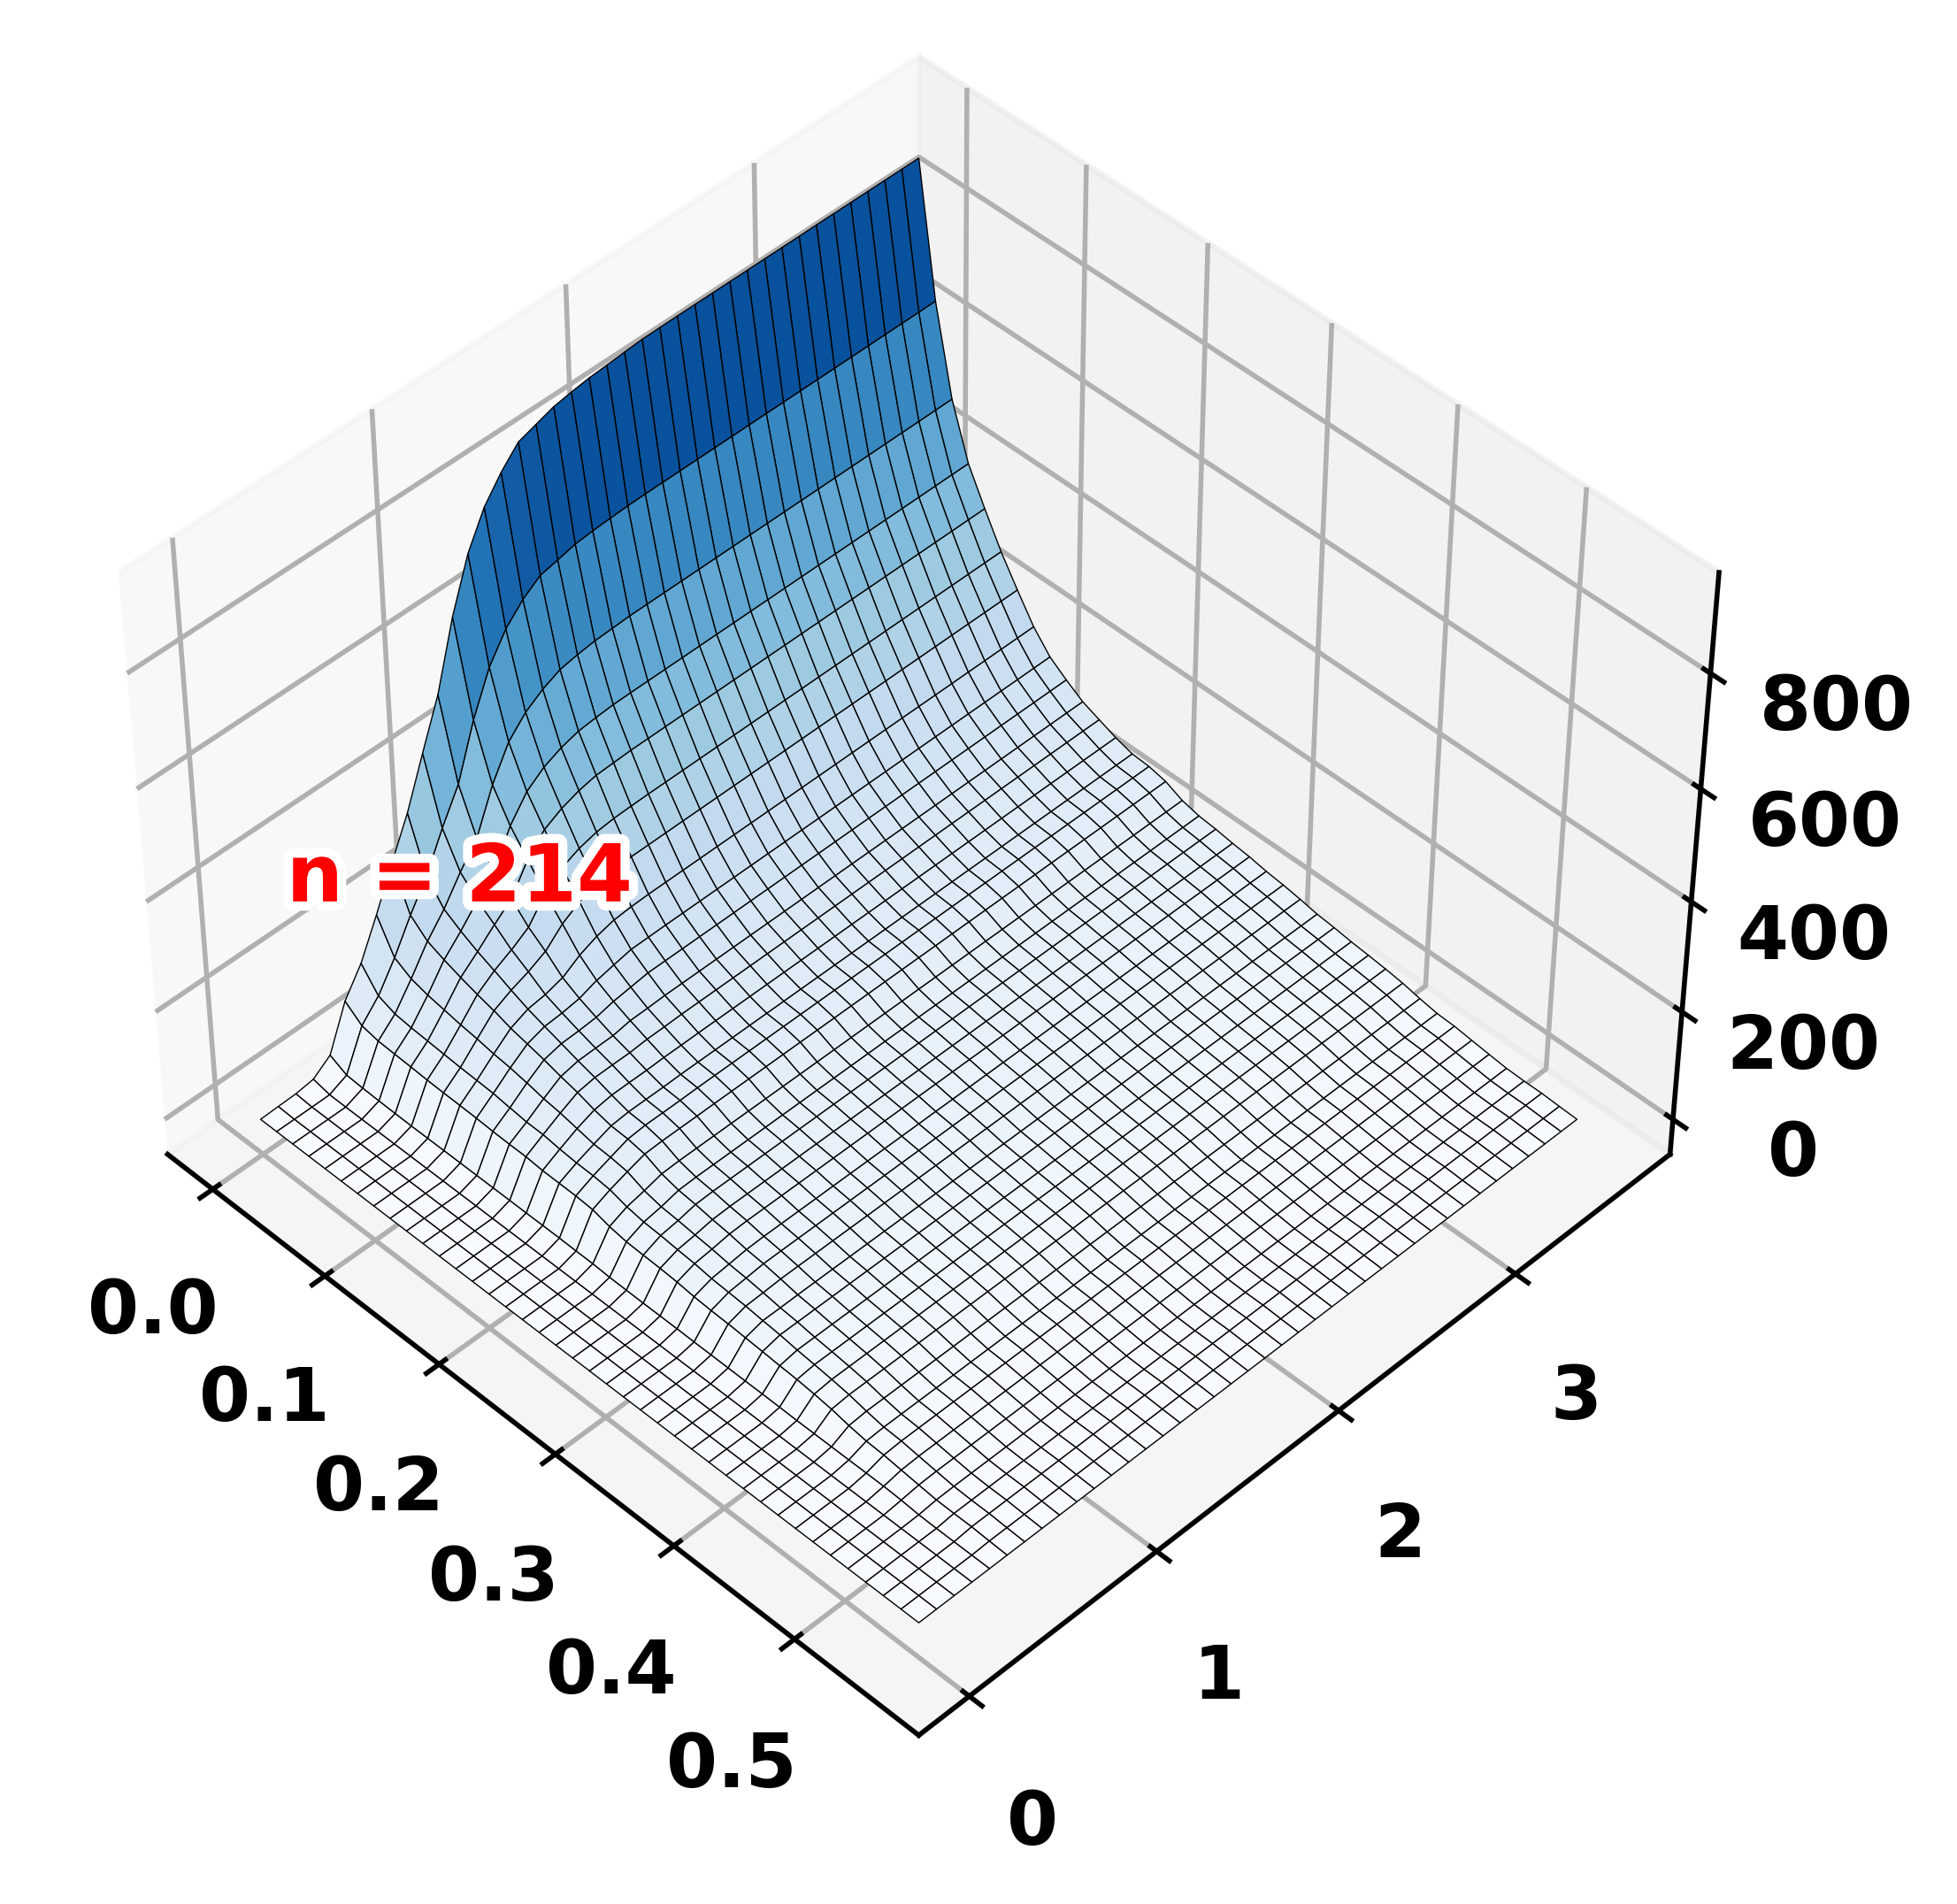

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 假设 X_mesh, Y_mesh, mean_r2_in, mean_r2_out, mean_n 已经定义

# ——— 1) 先找到“AD 内”R² 最大的阈值组合，同时取出该位置的 n retained ——— #
flat_in = np.nanargmax(mean_r2_in)
i_best, j_best = np.unravel_index(flat_in, mean_r2_in.shape)
rho_best = X_mesh[i_best, j_best]
ia_best  = Y_mesh[i_best, j_best]
n_best   = mean_n[i_best, j_best]   # 对应的样本数

# ——— 绘图 ——— #
fig1 = plt.figure(figsize=(6, 5), dpi=500)
ax1 = fig1.add_subplot(1, 1, 1, projection='3d')

surf1 = ax1.plot_surface(
    X_mesh, Y_mesh, mean_n,
    cmap='Blues',
    edgecolor='k',
    linewidth=0.2,
    antialiased=True,
    vmin=0, vmax=np.nanmax(mean_n)
)

# 坐标轴刻度加粗 & 放大
ax1.tick_params(axis='both', labelsize=12, width=1.5)
for t in ax1.get_xticklabels() + ax1.get_yticklabels() + ax1.get_zticklabels():
    t.set_fontweight('bold')

# 视角
ax1.view_init(elev=45, azim=-45)

# ——— 标注最佳点 ——— #
# 稍微抬高 z 值避免被 surface 遮挡
z_highlight = n_best + (np.nanmax(mean_n) * 0.03)

# 红色五角星
ax1.scatter(
    [rho_best], [ia_best], [z_highlight],
    color='red', s=200, marker='*', depthshade=False, zorder=10
)
# 注释文字
txt = ax1.text(
    rho_best, ia_best, z_highlight + (np.nanmax(mean_n) * 0.03),
    f"n = {int(n_best)}",
    color='red', fontsize=13, fontweight='bold',
    horizontalalignment='center', zorder=11
)
# 白色描边增强可读性
import matplotlib.patheffects as pe
txt.set_path_effects([
    pe.Stroke(linewidth=3, foreground='white'),
    pe.Normal()
])

plt.tight_layout()
plt.show()


/tmp/ipykernel_4274/2588311608.py:57: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


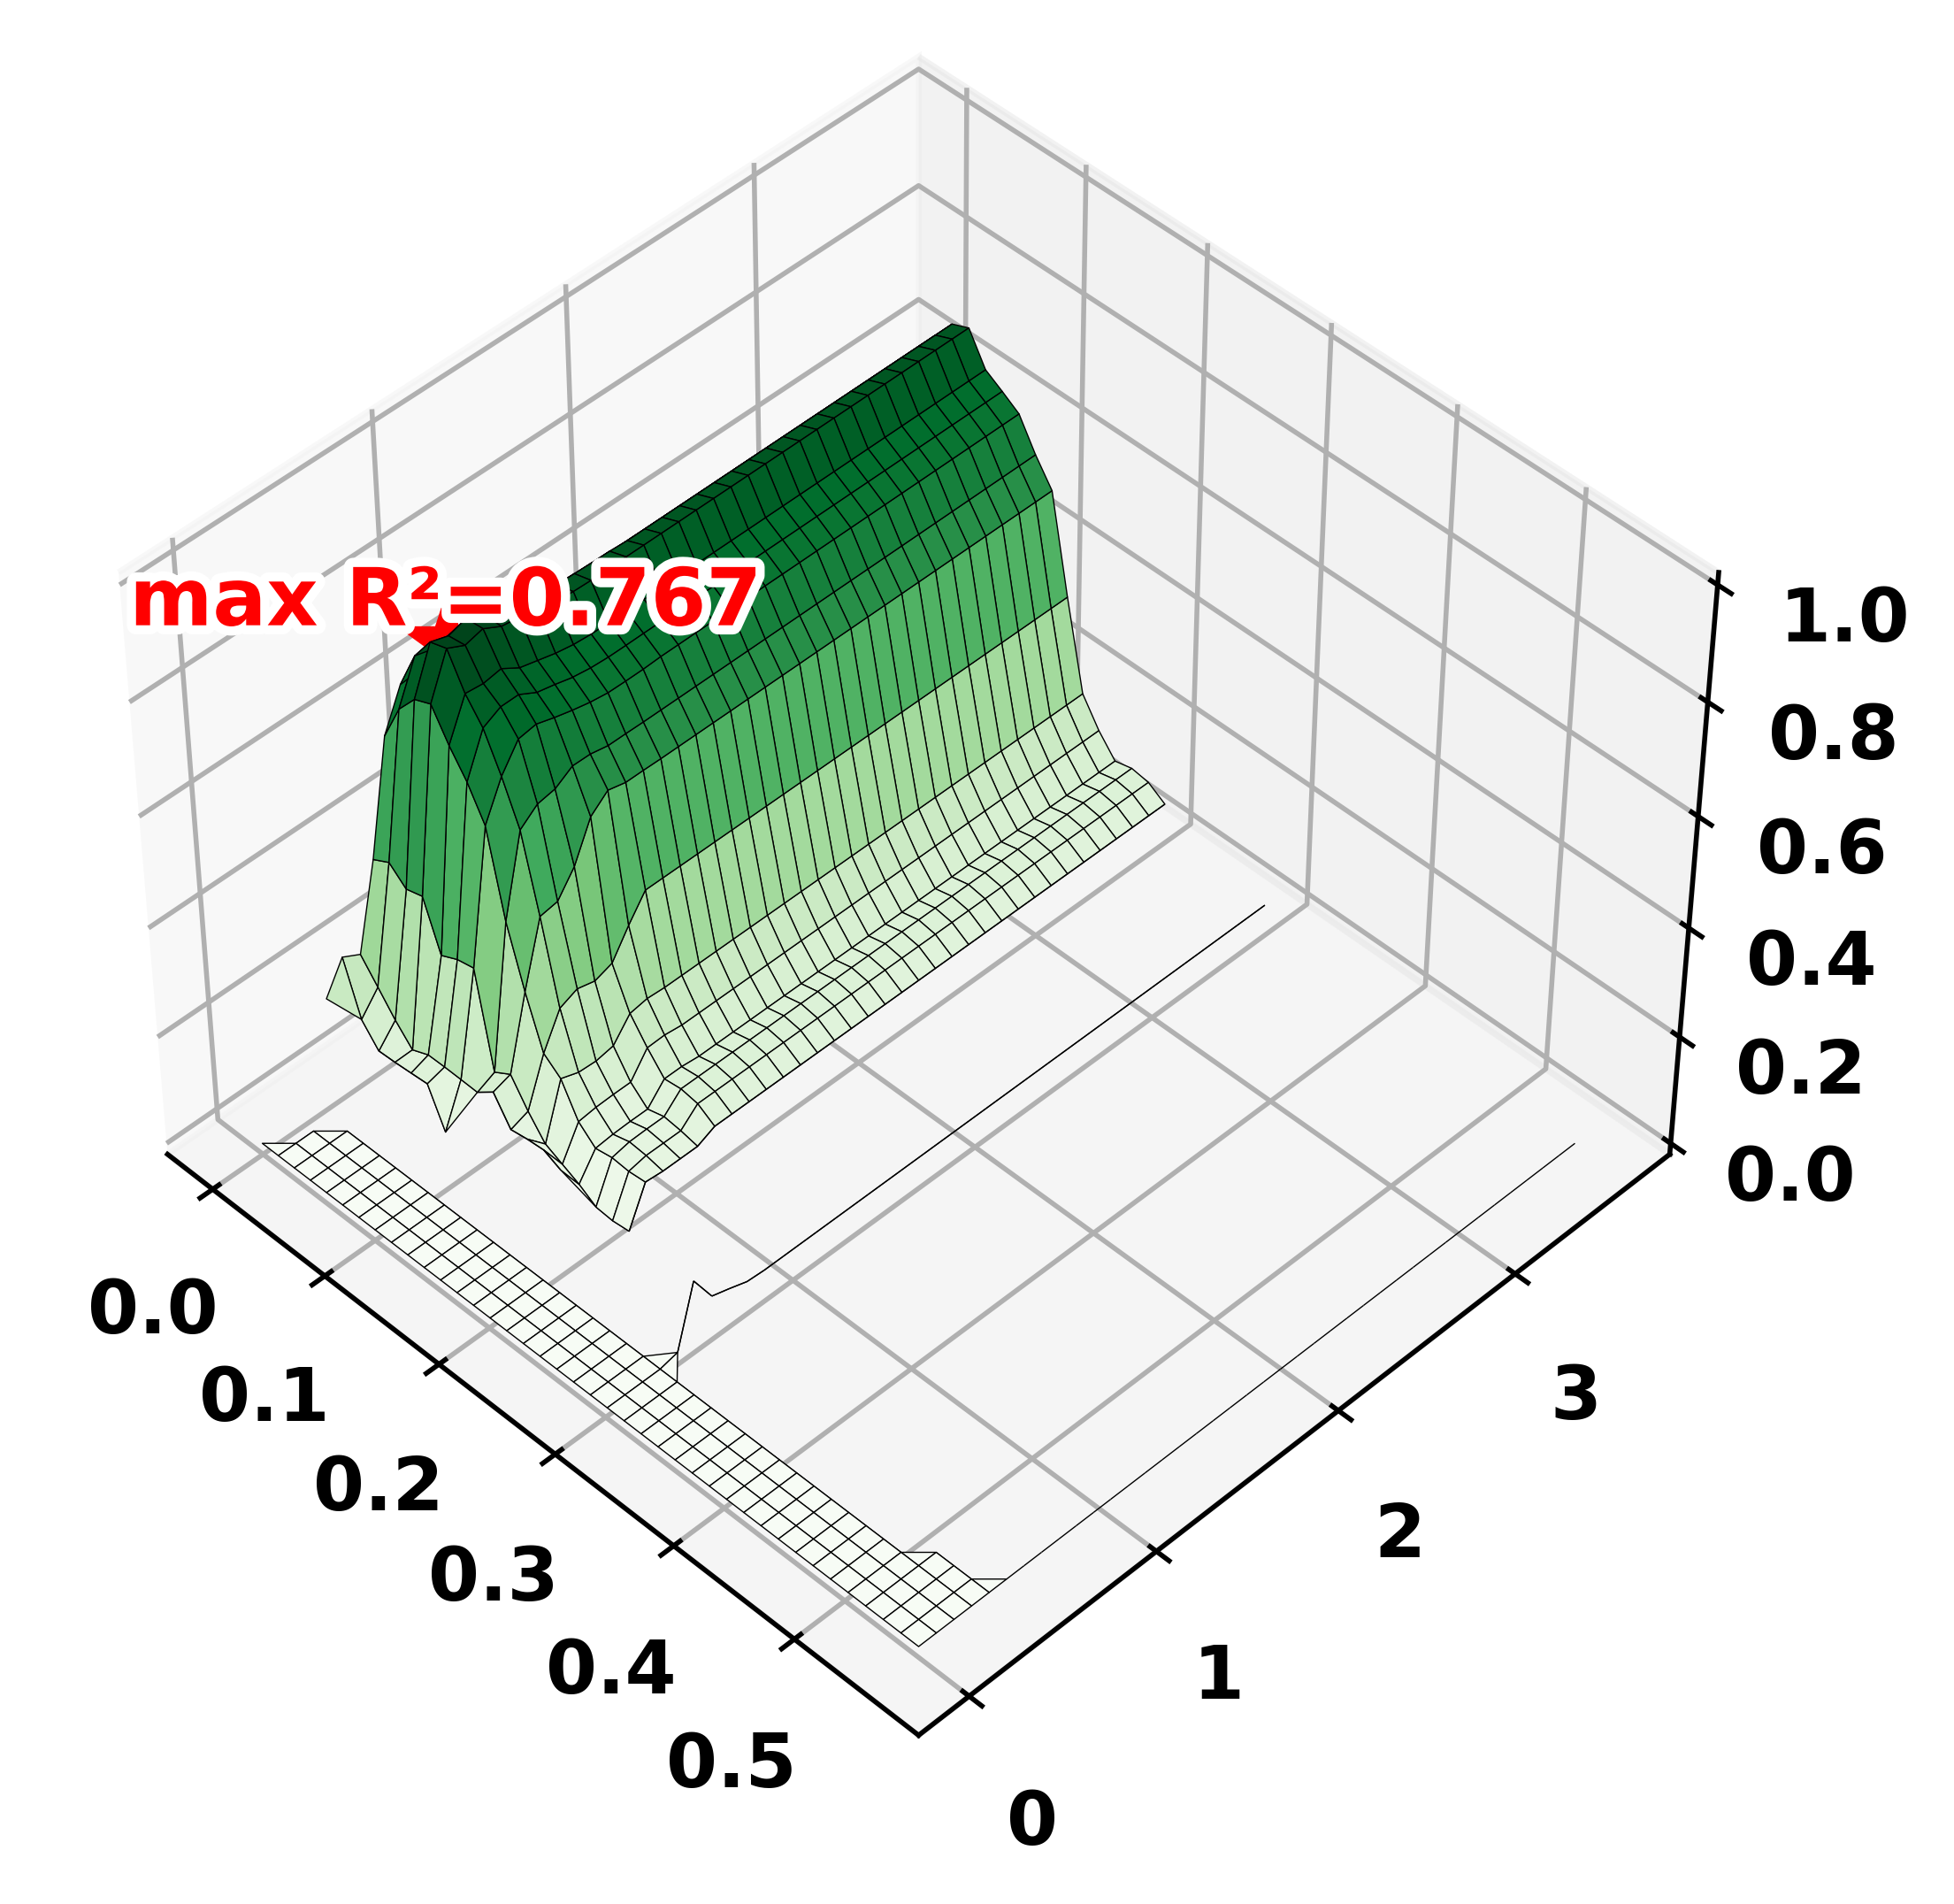

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe

fig1 = plt.figure(figsize=(6, 5), dpi=500)
ax1 = fig1.add_subplot(1, 1, 1, projection='3d')

Z_in = np.ma.masked_outside(mean_r2, 0, 1)
surf1 = ax1.plot_surface(
    X_mesh, Y_mesh, Z_in,
    cmap='Greens', edgecolor='k', linewidth=0.2, antialiased=True
)

ax1.set_zlim(0, 1)
# ax1.set_xlabel('ρₛ cutoff', labelpad=15, fontsize=13, fontweight='bold')
# ax1.set_ylabel('Iₐ cutoff', labelpad=15, fontsize=13, fontweight='bold')
# ax1.set_zlabel('R²',        labelpad=15, fontsize=13, fontweight='bold')
# ax1.set_title('R² within AD', pad=20, fontsize=14, fontweight='bold')

# 设置刻度字体加粗和大小
ax1.tick_params(axis='both', labelsize=12, width=1.5)
for t in ax1.get_xticklabels() + ax1.get_yticklabels() + ax1.get_zticklabels():
    t.set_fontweight('bold')

# colorbar
# cbar1 = fig1.colorbar(surf1, ax=ax1, shrink=0.6, pad=0.1)
# cbar1.set_label('R²', fontsize=12, fontweight='bold')
# cbar1.ax.tick_params(labelsize=10)
# for t in cbar1.ax.get_yticklabels():
#     t.set_fontweight('bold')

# best point
# best point (增强可视性)
# best point using five-pointed star marker
highlight_z = r2_in_best + 0.01  # 向上抬高，避免被 surface 遮挡

# 红色五角星标记
ax1.scatter(
    [rho_best], [ia_best], [highlight_z],
    color='red', s=200, marker='*', depthshade=False, zorder=10
)

# 添加文本标注
txt1 = ax1.text(
    rho_best, ia_best, highlight_z + 0.03,
    f"max R²={r2_in_best:.3f}",
    color='red', fontsize=13, fontweight='bold',
    horizontalalignment='center', zorder=11
)
txt1.set_path_effects([
    pe.Stroke(linewidth=3, foreground='white'),
    pe.Normal()
])


ax1.view_init(elev=45, azim=-45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4274/2675686368.py:54: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


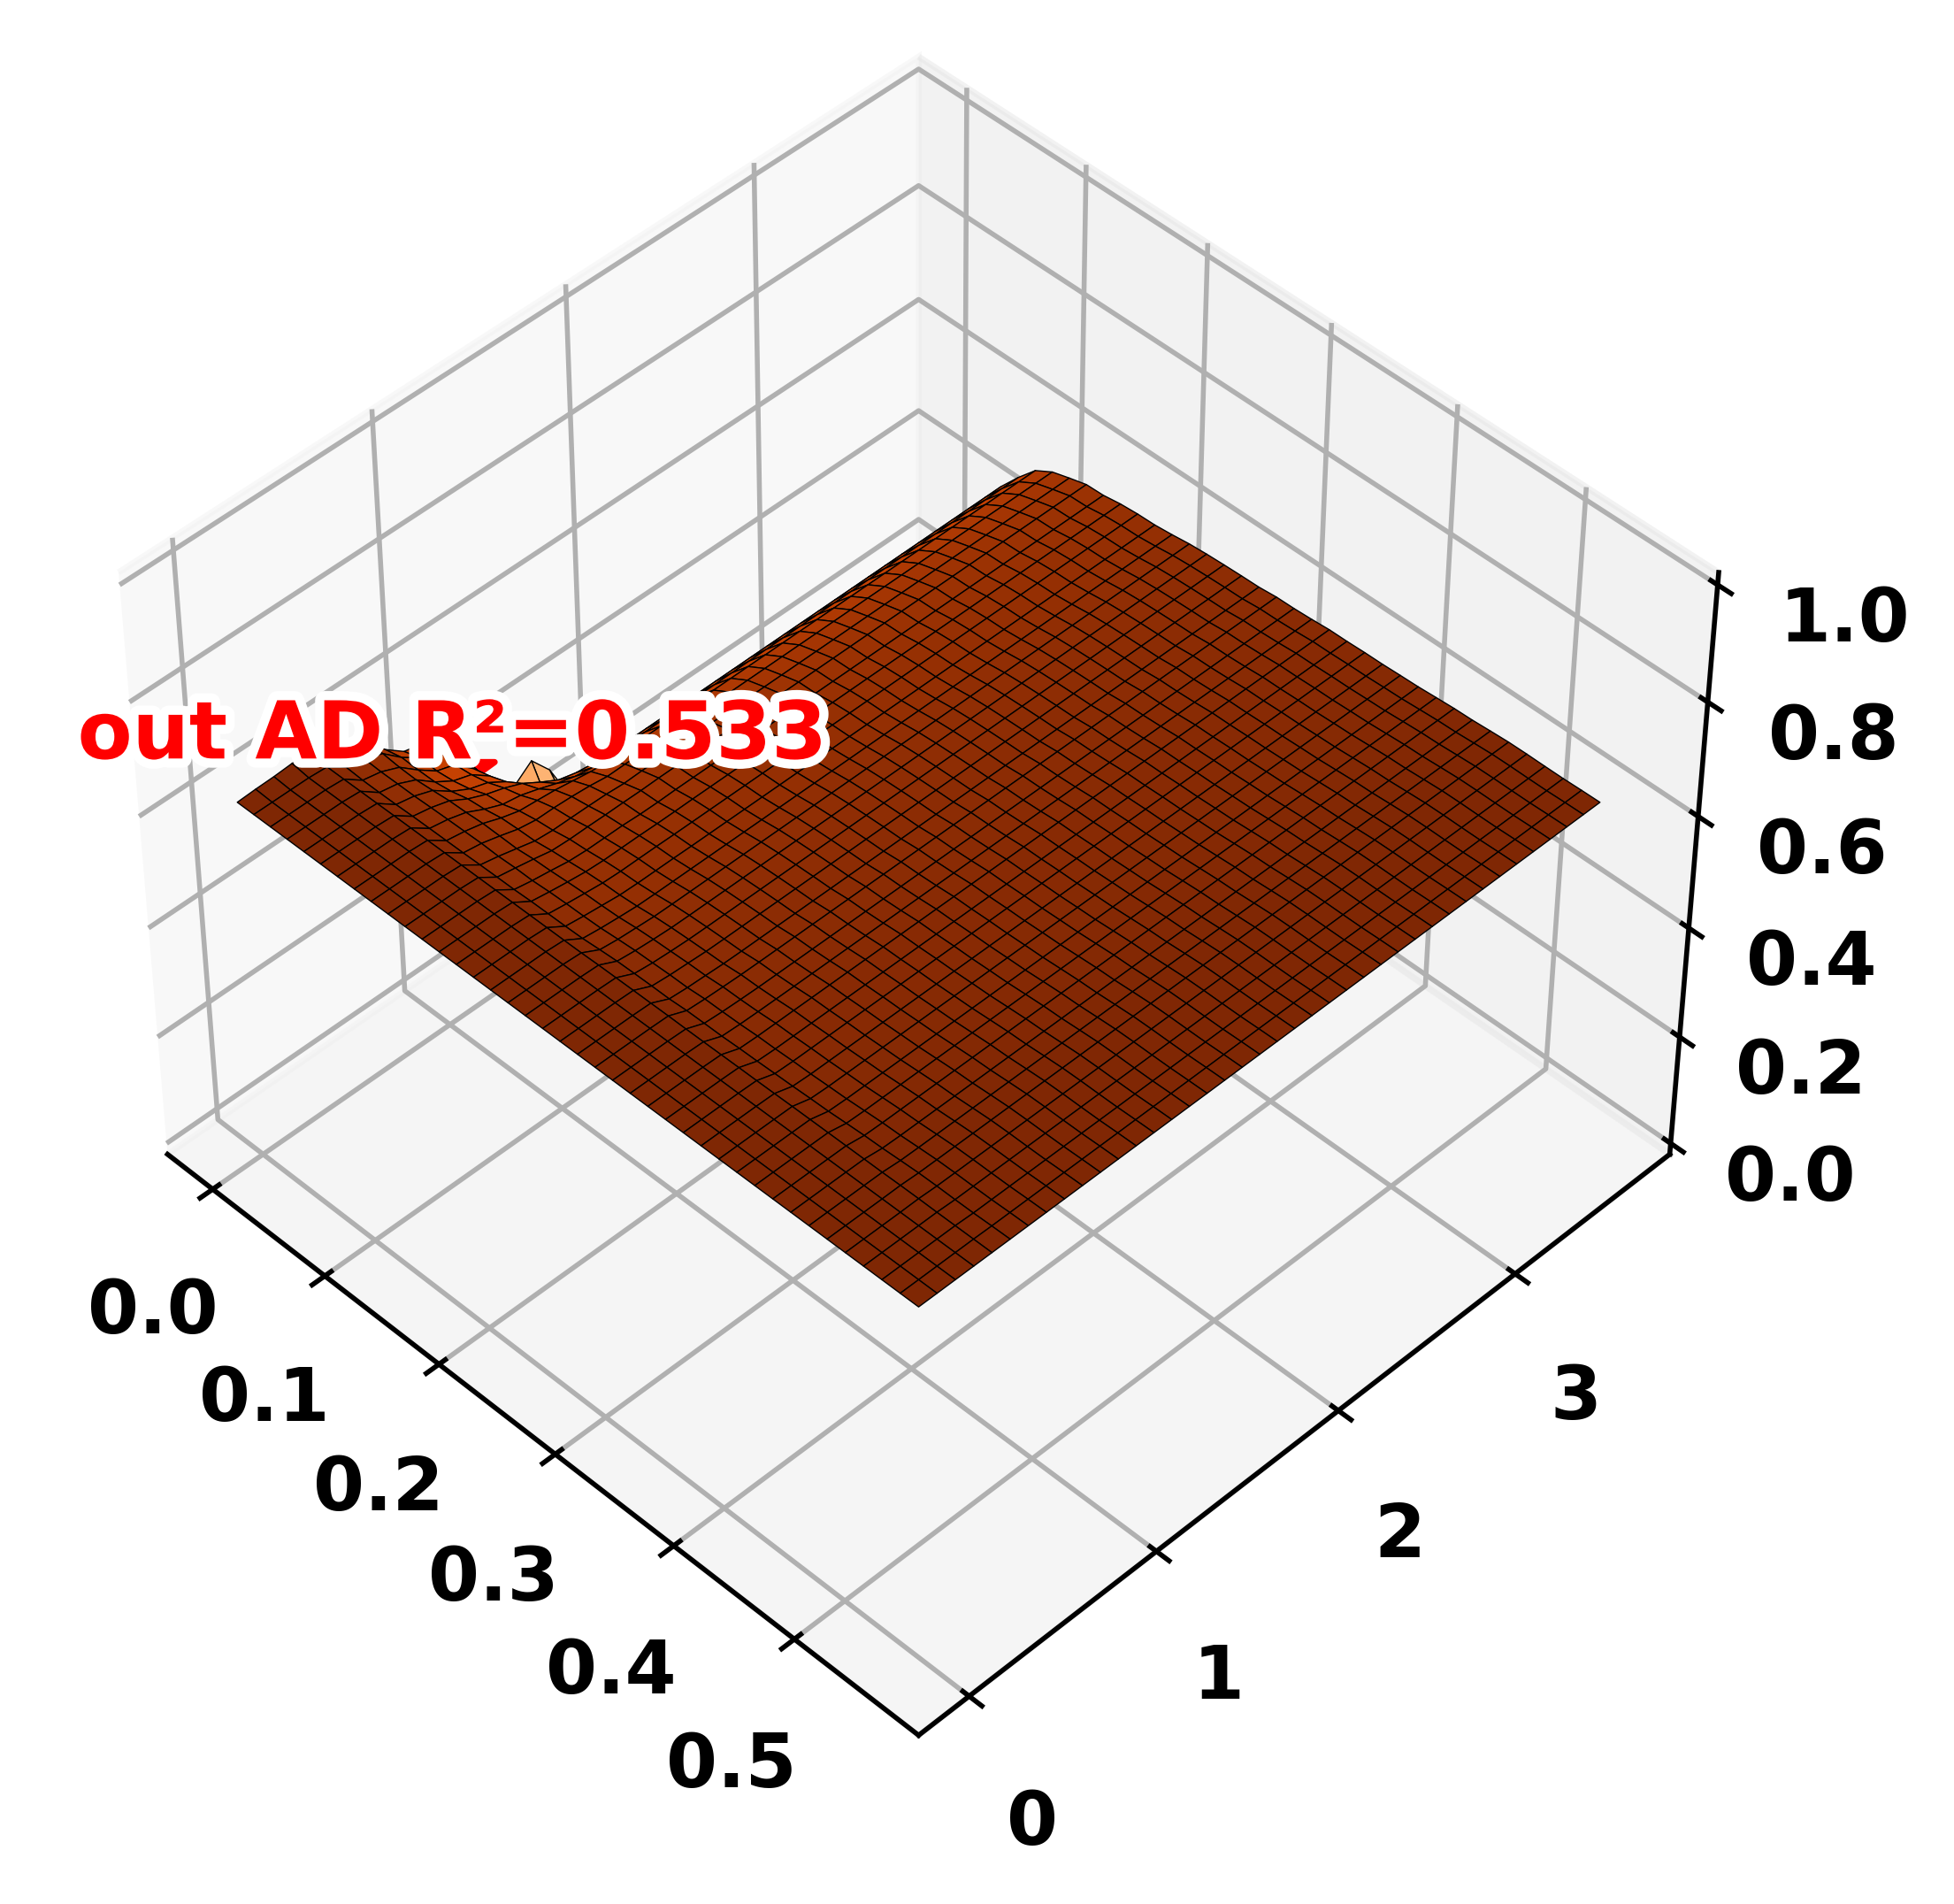

In [6]:
fig2 = plt.figure(figsize=(6, 5), dpi=500)
ax2 = fig2.add_subplot(1, 1, 1, projection='3d')

Z_out = np.ma.masked_outside(mean_r2_out, 0, 1)
surf2 = ax2.plot_surface(
    X_mesh, Y_mesh, Z_out,
    cmap='Oranges', edgecolor='k', linewidth=0.2, antialiased=True
)

ax2.set_zlim(0, 1)
# ax2.set_xlabel('ρₛ cutoff', labelpad=15, fontsize=13, fontweight='bold')
# ax2.set_ylabel('Iₐ cutoff', labelpad=15, fontsize=13, fontweight='bold')
# ax2.set_zlabel('R²',        labelpad=15, fontsize=13, fontweight='bold')
# ax2.set_title('R² outside AD', pad=20, fontsize=14, fontweight='bold')

# 设置刻度字体加粗和大小
ax2.tick_params(axis='both', labelsize=12, width=1.5)
for t in ax2.get_xticklabels() + ax2.get_yticklabels() + ax2.get_zticklabels():
    t.set_fontweight('bold')

# # colorbar
# cbar2 = fig2.colorbar(surf2, ax=ax2, shrink=0.6, pad=0.1)
# cbar2.set_label('R²_out', fontsize=12, fontweight='bold')
# cbar2.ax.tick_params(labelsize=10)
# for t in cbar2.ax.get_yticklabels():
#     t.set_fontweight('bold')

# best point
# best point using red five-pointed star
highlight_z_out = r2_out_best + 0.01  # 稍微抬高以避免被 surface 遮挡

# 红色五角星标记
ax2.scatter(
    [rho_best], [ia_best], [highlight_z_out],
    color='red', s=200, marker='*', depthshade=False, zorder=10
)

# 标注文字
txt2 = ax2.text(
    rho_best, ia_best, highlight_z_out + 0.03,
    f"out AD R²={r2_out_best:.3f}",
    color='red', fontsize=13, fontweight='bold',
    horizontalalignment='center', zorder=11
)
txt2.set_path_effects([
    pe.Stroke(linewidth=3, foreground='white'),
    pe.Normal()
])

ax2.view_init(elev=45, azim=-45)
#ax2.view_init(elev=30, azim=-60)


plt.tight_layout()
plt.show()
